# SentimentSense: IMDb Movie Review Classifier 🎬

Classify IMDb movie reviews as positive or negative with TF-IDF features and a
linear model.

**This notebook is a narrative over the `sentiment` package, not a second copy of
it.** Preprocessing, pipeline construction, training and evaluation all live in
`src/sentiment/` so the notebook, the test suite and the Streamlit app share one
implementation. Nothing here is duplicated logic that can drift.

### Before you start

```bash
pip install -e ".[app,data,notebook,dev]"
python download_data.py          # -> data/imdb_reviews.csv (no credentials needed)
```


## 1. Setup and data loading

The dataset comes from the Stanford aclImdb v1 release via `download_data.py`.
(The earlier version of this notebook called `kagglehub`, which silently required
a Kaggle API token nobody was told to configure.)


In [1]:
import sys
from pathlib import Path

# Allow running from a clone without `pip install -e .`
SRC = Path.cwd().parent / "src" if Path.cwd().name == "notebooks" else Path.cwd() / "src"
if SRC.is_dir() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sentiment.data import CLASS_NAMES, load_reviews
from sentiment.preprocessing import ENGLISH_STOPWORDS, NEGATION_WORDS, clean_text

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")

In [2]:
# `load_reviews` drops exact-duplicate reviews *before* anything else touches the
# data. The raw corpus contains a few hundred byte-identical reviews; if they
# survive into the train/test split the same text lands on both sides and the
# reported accuracy is inflated by leakage.
CSV_PATH = SRC.parent / "data" / "imdb_reviews.csv"

raw = pd.read_csv(CSV_PATH)
df = load_reviews(CSV_PATH)

print(f"Rows in CSV:            {len(raw):,}")
print(f"After de-duplication:   {len(df):,}  ({len(raw) - len(df):,} duplicates removed)")
print(f"Positive rate:          {df['label'].mean():.1%}")
df.head()

Rows in CSV:            50,000
After de-duplication:   49,582  (418 duplicates removed)
Positive rate:          50.2%


,review,label
0,Bromwell High is a cartoon comedy. It ran at t...,1
1,Homelessness (or Houselessness as George Carli...,1
2,Brilliant over-acting by Lesley Ann Warren. Be...,1
3,This is easily the most underrated film inn th...,1
4,This is not the typical Mel Brooks film. It wa...,1


## 2. Text preprocessing

`clean_text` strips HTML, lowercases, drops non-alphabetic characters and removes
stopwords — with one deliberate deviation from the textbook recipe.

**Generic stopword lists delete negations.** Both NLTK's and scikit-learn's
English lists contain `no`, `not`, `nor`, `never`. Strip those and `"not good"`
and `"good"` become the identical token `good`, which puts a hard ceiling on a
sentiment model. We therefore subtract every negation from the stopword set and
use bigram TF-IDF so `not good` survives as its own feature.


In [3]:
sample = "This was NOT a good movie.<br /><br />I didn't enjoy it at all!"
print("raw    :", sample)
print("cleaned:", clean_text(sample))
print()

# The regression this guards against:
print("clean('this was not good') ->", repr(clean_text("this was not good")))
print("clean('this was good')     ->", repr(clean_text("this was good")))
assert clean_text("this was not good") != clean_text("this was good")

print()
print(f"{len(ENGLISH_STOPWORDS)} stopwords in use; "
      f"{len(NEGATION_WORDS)} negation tokens deliberately kept:")
print(", ".join(sorted(NEGATION_WORDS)))

raw    : This was NOT a good movie.<br /><br />I didn't enjoy it at all!
cleaned: not good movie didnt enjoy

clean('this was not good') -> 'not good'
clean('this was good')     -> 'good'

294 stopwords in use; 37 negation tokens deliberately kept:
against, aint, although, arent, but, cannot, cant, couldnt, didnt, doesnt, dont, hadnt, hasnt, havent, however, isnt, least, less, neither, never, no, nobody, none, nor, not, nothing, nowhere, only, shouldnt, though, too, very, wasnt, werent, without, wont, wouldnt


## 3. Exploratory data analysis

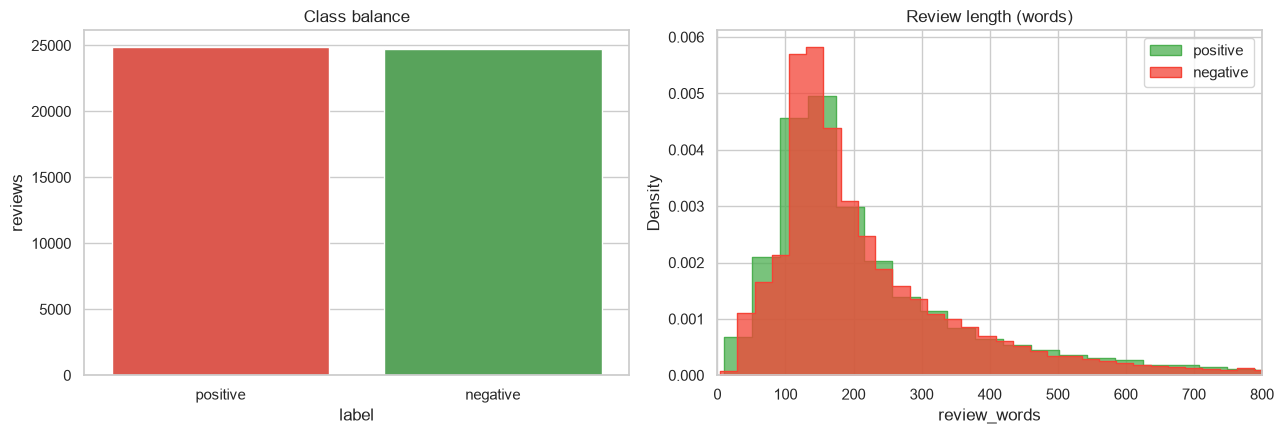

count    49582.0
mean       231.4
std        171.5
min          4.0
25%        126.0
50%        173.0
75%        281.0
max       2470.0
Name: review_words, dtype: float64

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

counts = df["label"].map({0: "negative", 1: "positive"}).value_counts()
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=["#f44336", "#4caf50"], legend=False, ax=axes[0])
axes[0].set_title("Class balance")
axes[0].set_ylabel("reviews")

df["review_words"] = df["review"].str.split().str.len()
for label, colour in [(1, "#4caf50"), (0, "#f44336")]:
    sns.histplot(df.loc[df["label"] == label, "review_words"], bins=60,
                 color=colour, label=CLASS_NAMES[label], kde=False,
                 stat="density", element="step", ax=axes[1])
axes[1].set_xlim(0, 800)
axes[1].set_title("Review length (words)")
axes[1].legend()
plt.tight_layout()
plt.show()

df["review_words"].describe().round(1)

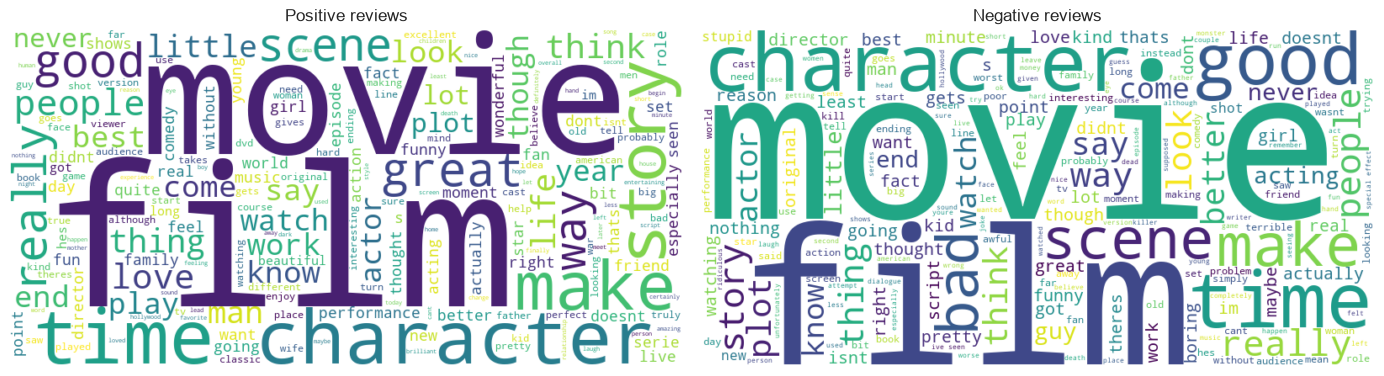

In [5]:
from wordcloud import WordCloud

# Word clouds run on *cleaned* text so they reflect what the model actually sees.
eda_sample = df.sample(min(5000, len(df)), random_state=RANDOM_STATE)
cleaned = eda_sample["review"].map(clean_text)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, label, title in [(axes[0], 1, "Positive"), (axes[1], 0, "Negative")]:
    text = " ".join(cleaned[eda_sample["label"] == label])
    wc = WordCloud(width=800, height=400, background_color="white",
                   random_state=RANDOM_STATE).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(f"{title} reviews")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Splitting the data — and what the original notebook got wrong

Three changes, all of which move the headline number *down* and make it real:

| Original | Here | Why |
| --- | --- | --- |
| duplicates kept | dropped before splitting | identical reviews on both sides of the split leak test data into training |
| `train_test_split(...)` unstratified | `stratify=y` | on a subsample the class ratio drifts, so accuracy is measured against a moving target |
| model chosen by comparing test scores | chosen by cross-validation on **train only** | picking the winner on the test set means the reported score is selection-biased and optimistic |

There is also now a **majority-class baseline**. "88% accuracy" is meaningless
until you know what guessing the most common label scores.


In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

X = df["review"].tolist()
y = df["label"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))

print(f"train {len(X_train):,} / test {len(X_test):,}")
print(f"positive rate  train {y_train.mean():.3f}  test {y_test.mean():.3f}  (stratified)")
print(f"majority-class baseline accuracy: {baseline_acc:.4f}   <- beat this")

train 39,665 / test 9,917
positive rate  train 0.502  test 0.502  (stratified)
majority-class baseline accuracy: 0.5019   <- beat this


## 5. Model selection by cross-validation

Naive Bayes and Logistic Regression are compared with 5-fold stratified CV **on
the training split only**. The test set stays sealed until section 6.


In [7]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

from sentiment.model import build_pipeline

candidates = {
    "MultinomialNB (unigram)": build_pipeline("nb", ngram_range=(1, 1)),
    "MultinomialNB (uni+bigram)": build_pipeline("nb", ngram_range=(1, 2)),
    "LogisticRegression (unigram)": build_pipeline("logreg", ngram_range=(1, 1)),
    "LogisticRegression (uni+bigram)": build_pipeline("logreg", ngram_range=(1, 2)),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
for name, pipe in candidates.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    rows.append({"model": name, "cv_roc_auc": scores.mean(), "std": scores.std()})
    print(f"{name:34s} ROC-AUC {scores.mean():.4f} +/- {scores.std():.4f}")

cv_results = pd.DataFrame(rows).sort_values("cv_roc_auc", ascending=False).reset_index(drop=True)
cv_results

MultinomialNB (unigram)            ROC-AUC 0.9374 +/- 0.0037


MultinomialNB (uni+bigram)         ROC-AUC 0.9499 +/- 0.0035


LogisticRegression (unigram)       ROC-AUC 0.9591 +/- 0.0023


LogisticRegression (uni+bigram)    ROC-AUC 0.9636 +/- 0.0022


,model,cv_roc_auc,std
0,LogisticRegression (uni+bigram),0.963612,0.002174
1,LogisticRegression (unigram),0.959113,0.002290
2,MultinomialNB (uni+bigram),0.949912,0.003541
3,MultinomialNB (unigram),0.937391,0.003703


In [8]:
# Fit both families on the full training split so section 6 can show a confusion
# matrix for each -- the original notebook only ever plotted one.
nb_model = build_pipeline("nb", ngram_range=(1, 2)).fit(X_train, y_train)
lr_model = build_pipeline("logreg", ngram_range=(1, 2)).fit(X_train, y_train)

best_name = cv_results.iloc[0]["model"]
best_model = nb_model if best_name.startswith("MultinomialNB") else lr_model
print(f"CV winner: {best_name}")

CV winner: LogisticRegression (uni+bigram)


## 6. Evaluation on the held-out test set

Both models are scored here for comparison, but only the CV winner's number is
the honest headline — the other is shown for illustration, not selection.


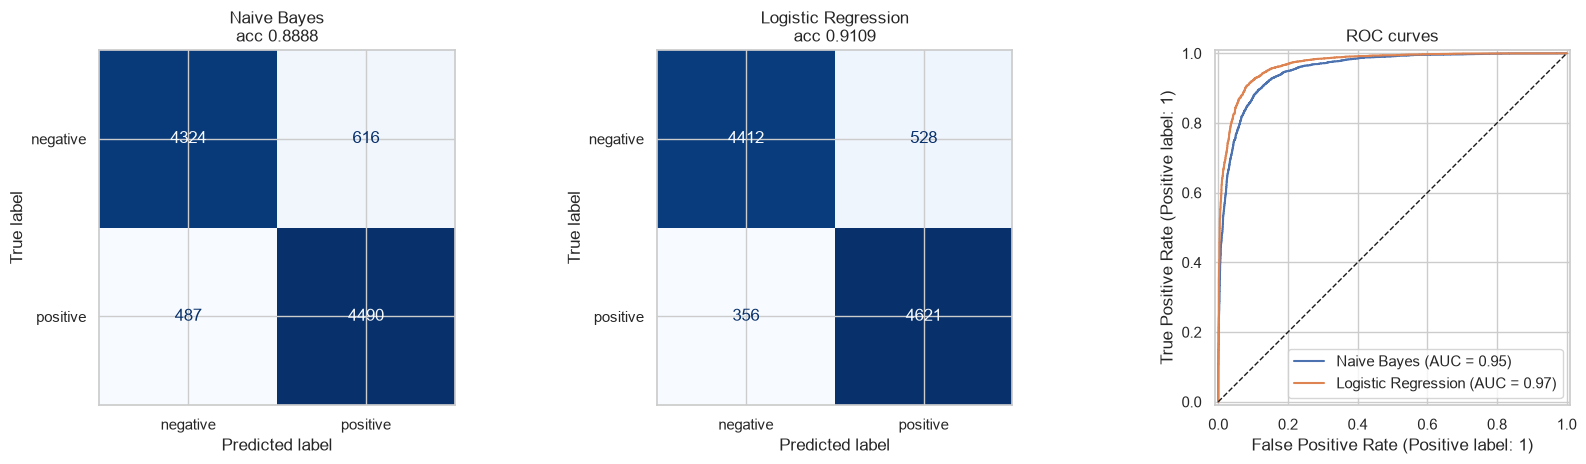

=== LogisticRegression (uni+bigram) on the held-out test set ===
accuracy 0.9109  (baseline 0.5019)   ROC-AUC 0.9698
              precision    recall  f1-score   support

    negative       0.93      0.89      0.91      4940
    positive       0.90      0.93      0.91      4977

    accuracy                           0.91      9917
   macro avg       0.91      0.91      0.91      9917
weighted avg       0.91      0.91      0.91      9917



In [9]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
    confusion_matrix, roc_auc_score,
)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (name, model) in zip(axes[:2], [("Naive Bayes", nb_model),
                                        ("Logistic Regression", lr_model)]):
    pred = model.predict(X_test)
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, pred), display_labels=CLASS_NAMES
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nacc {accuracy_score(y_test, pred):.4f}")

for name, model in [("Naive Bayes", nb_model), ("Logistic Regression", lr_model)]:
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=axes[2])
axes[2].plot([0, 1], [0, 1], "k--", lw=1)
axes[2].set_title("ROC curves")
plt.tight_layout()
plt.show()

y_pred = best_model.predict(X_test)
proba_pos = best_model.predict_proba(X_test)[:, 1]
print(f"=== {best_name} on the held-out test set ===")
print(f"accuracy {accuracy_score(y_test, y_pred):.4f}  "
      f"(baseline {baseline_acc:.4f})   ROC-AUC {roc_auc_score(y_test, proba_pos):.4f}")
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

## 7. Error analysis

The most valuable section of any classification write-up, and the one the
original notebook was missing entirely. A confusion matrix tells you *how many*
you got wrong; these tell you *why*.


In [10]:
from sentiment.model import top_coefficients
from sentiment.train import error_analysis

errors = error_analysis(X_test, y_test, y_pred, proba_pos, n=5)

for kind, heading in [("false_positives", "Predicted POSITIVE, actually negative"),
                      ("false_negatives", "Predicted NEGATIVE, actually positive")]:
    print("=" * 100)
    print(f"{heading} -- the {len(errors[kind])} the model was most confident about")
    print("=" * 100)
    for item in errors[kind]:
        print(f"[p={item['confidence']:.3f}] {item['review'][:300]}...")
        print("-" * 100)

Predicted POSITIVE, actually negative -- the 5 the model was most confident about
[p=0.975] this one of the best celebrity's reality shows a ever saw. we can see the concerts we can see the life of Britney, i love the five episodes. i was always being surprised by Britney and the subjects of the show i think that some people don't watch the show at all we can how a great person she his. sh...
----------------------------------------------------------------------------------------------------
[p=0.960] I was so eager to see this one of my favorite TV shows.I saw Universal trademark followed with a newly acquainted title and theme song which still impress me.Computer animation on some scenery like a solid title name"The Jetsons" or a dimension view of a spaceship approaching an amusement park and m...
----------------------------------------------------------------------------------------------------
[p=0.958] Lois Weber's film "Hypocrites" was and still kind of is a very bold and daring

In [11]:
# What drives the decision: the strongest signed TF-IDF weights.
# Watch for negated bigrams ("not worth", "no plot") in the negative column --
# those only exist because negations survive preprocessing.
coefs = top_coefficients(lr_model, n=20)
weights = pd.DataFrame({
    "positive feature": [w for w, _ in coefs["positive"]],
    "weight (+)": [round(c, 3) for _, c in coefs["positive"]],
    "negative feature": [w for w, _ in coefs["negative"]],
    "weight (-)": [round(c, 3) for _, c in coefs["negative"]],
})
weights

,positive feature,weight (+),negative feature,weight (-)
0,great,8.721,worst,-10.532
1,excellent,7.181,bad,-8.669
2,best,6.344,awful,-7.672
3,perfect,5.531,waste,-6.832
4,wonderful,5.063,boring,-6.816
5,amazing,4.978,poor,-6.355
6,loved,4.964,terrible,-6.132
7,brilliant,4.710,nothing,-5.937
8,favorite,4.527,worse,-5.395
9,fun,4.314,dull,-4.833


## 8. Persist the model for the Streamlit demo

`python -m sentiment.train` does everything above as a single reproducible
command — grid search, honest evaluation, error analysis — and writes
`models/sentiment_pipeline.joblib` plus a JSON metrics report. The Streamlit app
loads exactly that artifact, so the demo shows the real model's probabilities and
the real test accuracy rather than made-up numbers.

```bash
python -m sentiment.train
streamlit run app.py
```


In [12]:
# Equivalent to running the CLI, from inside the notebook:
# from sentiment.train import train
# bundle = train()
# print(bundle.metrics["test_accuracy"])